# Fase 1 - Relatório visual dos resultados (MLP no CIFAR-10)

Este notebook **não treina nada** — só lê tudo que já está salvo em `../results/` (skill `model-saver`) e gera os gráficos usados no relatório do `../README.md`. Cada gráfico é salvo como PNG em `../results/plots/report/`, para poder ser referenciado diretamente no README com `![](...)`.

Separar isso do `01_train_mlp_cifar10.ipynb` (que define e roda experimentos) evita reprocessar/retreinar nada só para gerar uma figura, e mantém o notebook de treino focado em orquestrar experimentos.

## 0. Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent  # notebooks/ -> fase1-mlp/
sys.path.insert(0, str(PROJECT_ROOT / "src"))

DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
PLOTS_DIR = RESULTS_DIR / "plots" / "report"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("PLOTS_DIR:", PLOTS_DIR)

PROJECT_ROOT: C:\Users\jplim\Documents\Programação\redes-neurais\miniprojeto\fase1-mlp
PLOTS_DIR: C:\Users\jplim\Documents\Programação\redes-neurais\miniprojeto\fase1-mlp\results\plots\report


In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix

from mlp_cifar10.checkpointing import load_all_metadata
from mlp_cifar10.data import get_dataloaders, CLASSES
from mlp_cifar10.model import MLP

plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"

## 1. Carregando todas as execuções salvas

In [ ]:
df_all = load_all_metadata(RESULTS_DIR)

# O ensemble não é uma execução de treino (sem run_name/hyperparameters de
# treino) — separa para não quebrar as tabelas/gráficos abaixo, que assumem
# uma execução com run_name. "final" é o melhor ensemble encontrado (ver
# scripts/ensemble_eval.py); os outros ensembles testados
# (search_top3_round6/search_top4_mixed/search_top5_by_accuracy) ficam em
# results/ só como registro da busca de composição do ensemble.
ensemble_meta = json.loads((RESULTS_DIR / "mlp_ensemble_final_softvote" / "metadata.json").read_text(encoding="utf-8"))
df = df_all[df_all["run_name"].notna()].copy()
df = df.sort_values("metrics.test_accuracy", ascending=False).reset_index(drop=True)

print(f"{len(df)} execuções de treino carregadas de {RESULTS_DIR} (+ ensembles)")
df[["run_name", "metrics.test_accuracy", "metrics.test_f1_score", "metrics.epochs_trained"]].head(10)

## 2. Ranking geral — top 15 execuções por acurácia de teste

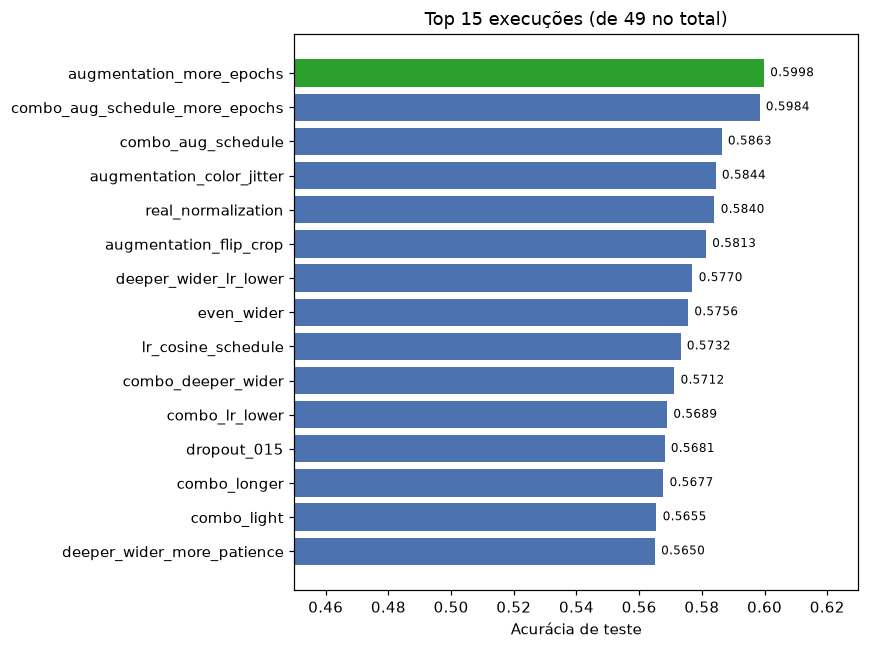

In [4]:
top_n = 15
top_df = df.head(top_n).iloc[::-1]  # inverte para o maior ficar no topo do barh

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#2ca02c" if i == len(top_df) - 1 else "#4c72b0" for i in range(len(top_df))]
ax.barh(top_df["run_name"], top_df["metrics.test_accuracy"], color=colors)
for i, (_, row) in enumerate(top_df.iterrows()):
    ax.text(row["metrics.test_accuracy"] + 0.002, i, f"{row['metrics.test_accuracy']:.4f}", va="center", fontsize=8)
ax.set_xlabel("Acurácia de teste")
ax.set_title(f"Top {top_n} execuções (de {len(df)} no total)")
ax.set_xlim(0.45, max(top_df["metrics.test_accuracy"]) + 0.03)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "top15_accuracy.png")
plt.show()

## 3. Evolução da busca: melhor acurácia por rodada

Mapeamento manual de `run_name -> rodada`, refletindo a ordem real em que os experimentos foram decididos e rodados (baseline = 17 execuções originais do notebook `01`; rodadas 1-6 = `scripts/run_experiments.py`; ensemble = `scripts/ensemble_eval.py`, sem retreino).

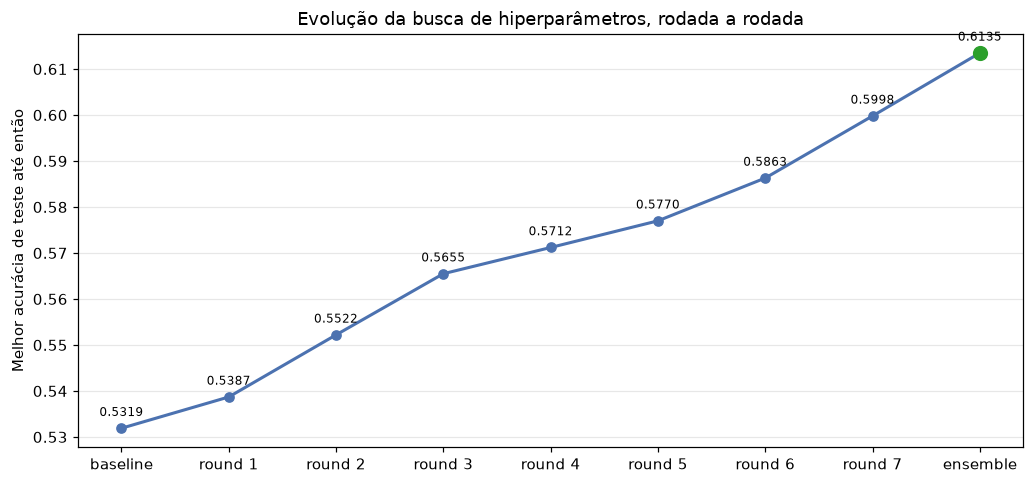

In [5]:
ROUND_RUNS = {
    0: [
        "baseline_relu_adam", "deeper_dropout", "sgd_momentum", "activation_tanh",
        "activation_gelu", "activation_leaky_relu", "dropout_only", "weight_decay_low",
        "weight_decay_high", "batch_norm", "loss_mse", "wider_single_layer",
        "narrow_shallow", "lr_low", "lr_high", "large_batch", "best_combo",
    ],
    1: ["more_patience", "even_deeper", "dropout_higher", "gelu_combo", "wd_higher"],
    2: ["even_deeper_more_epochs", "gelu_even_deeper", "wider_still", "dropout_lighter", "no_weight_decay"],
    3: ["combo_light", "deeper_wider2", "longer_training", "lr_higher", "five_layer"],
    4: ["combo_deeper_wider", "combo_dropout_01", "combo_longer", "combo_lr_lower", "six_layer_combo"],
    5: ["deeper_wider_lr_lower", "deeper_wider_more_patience", "dropout_015", "even_wider", "relu_deeper_wider"],
    6: ["augmentation_flip_crop", "lr_cosine_schedule", "combo_aug_schedule"],
    7: ["augmentation_more_epochs", "combo_aug_schedule_more_epochs", "real_normalization", "augmentation_color_jitter"],
}

run_to_round = {name: r for r, names in ROUND_RUNS.items() for name in names}
df["round"] = df["run_name"].map(run_to_round)

best_by_round = df.dropna(subset=["round"]).groupby("round")["metrics.test_accuracy"].max()
best_by_round = best_by_round.cummax()  # melhor-até-agora, monotonicamente crescente

ensemble_acc = ensemble_meta["metrics"]["test_accuracy"]

x_labels = ["baseline"] + [f"round {r}" for r in range(1, 8)] + ["ensemble"]
y_values = list(best_by_round.values) + [ensemble_acc]

fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.plot(x_labels, y_values, marker="o", linewidth=2, color="#4c72b0")
for x, y in zip(x_labels, y_values):
    ax.annotate(f"{y:.4f}", (x, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)
ax.scatter([x_labels[-1]], [y_values[-1]], color="#2ca02c", s=80, zorder=5)
ax.set_ylabel("Melhor acurácia de teste até então")
ax.set_title("Evolução da busca de hiperparâmetros, rodada a rodada")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "evolucao_por_rodada.png")
plt.show()

## 4. Curvas de treino do melhor modelo individual (`augmentation_more_epochs`)

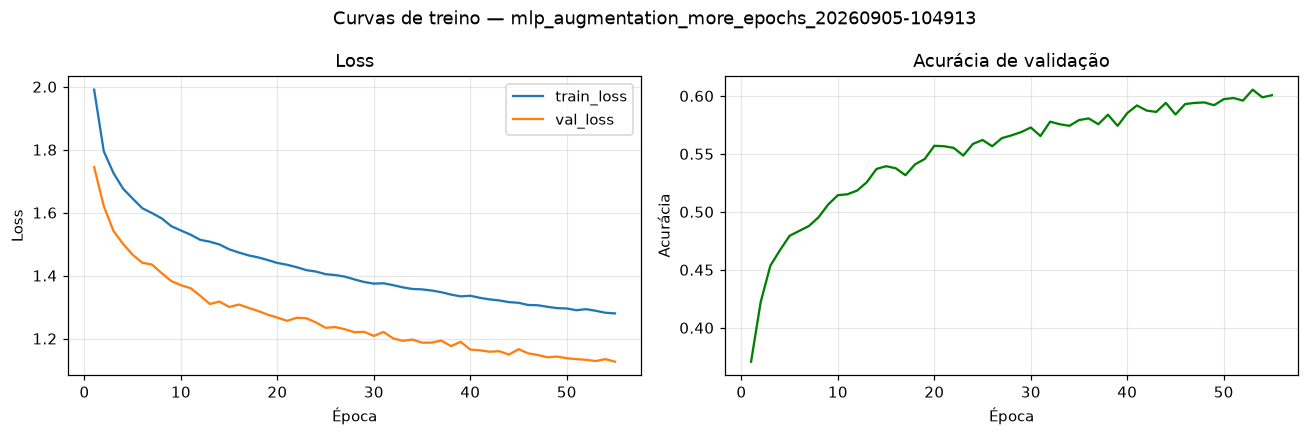

In [6]:
best_row = df.iloc[df["run_name"].eq("augmentation_more_epochs").idxmax()] if "augmentation_more_epochs" in df["run_name"].values else df.iloc[0]
best_model_id = best_row["model_id"]
history_path = RESULTS_DIR / best_model_id / "history.csv"
history_df = pd.read_csv(history_path)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
axes[0].set_xlabel("Época"); axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].set_title("Loss")
axes[0].grid(alpha=0.3)

axes[1].plot(history_df["epoch"], history_df["val_accuracy"], color="green")
axes[1].set_xlabel("Época"); axes[1].set_ylabel("Acurácia"); axes[1].set_title("Acurácia de validação")
axes[1].grid(alpha=0.3)

fig.suptitle(f"Curvas de treino — {best_model_id}")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "training_curves_melhor_modelo.png")
plt.show()

## 5. Acurácia por classe: melhor modelo individual vs. ensemble

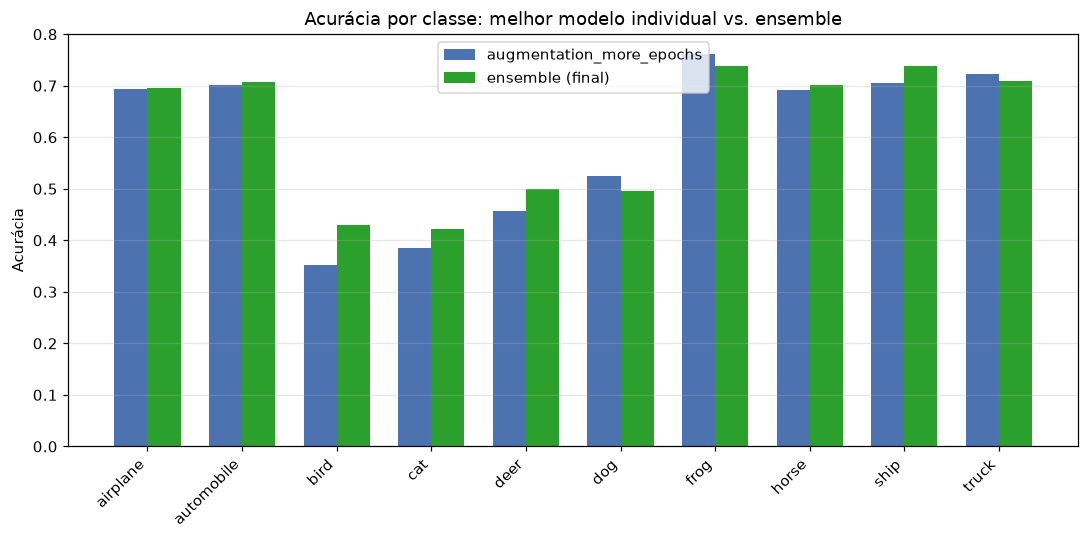

In [7]:
def per_class_from_metadata(model_id):
    meta = json.loads((RESULTS_DIR / model_id / "metadata.json").read_text(encoding="utf-8"))
    return meta["per_class_accuracy"]

individual_pc = per_class_from_metadata(best_model_id)
ensemble_pc = ensemble_meta["per_class_accuracy"]

classes = list(CLASSES)
x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width / 2, [individual_pc[c] for c in classes], width, label=f"{best_model_id.replace('mlp_', '').rsplit('_', 1)[0]}", color="#4c72b0")
ax.bar(x + width / 2, [ensemble_pc[c] for c in classes], width, label="ensemble (final)", color="#2ca02c")
ax.set_xticks(x); ax.set_xticklabels(classes, rotation=45, ha="right")
ax.set_ylabel("Acurácia")
ax.set_title("Acurácia por classe: melhor modelo individual vs. ensemble")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "per_class_comparison.png")
plt.show()

## 6. Matriz de confusão do ensemble

Recarrega os 3 modelos membros do **ensemble final** (`mlp_ensemble_final_softvote`) só para inferência — nenhum retreino, apenas forward pass no conjunto de teste. Esses membros foram escolhidos por diversidade de regime de treino (não só por acurácia individual): `augmentation_more_epochs` e `combo_aug_schedule_more_epochs` usam augmentation, `deeper_wider_lr_lower` não — ver `scripts/ensemble_eval.py`.

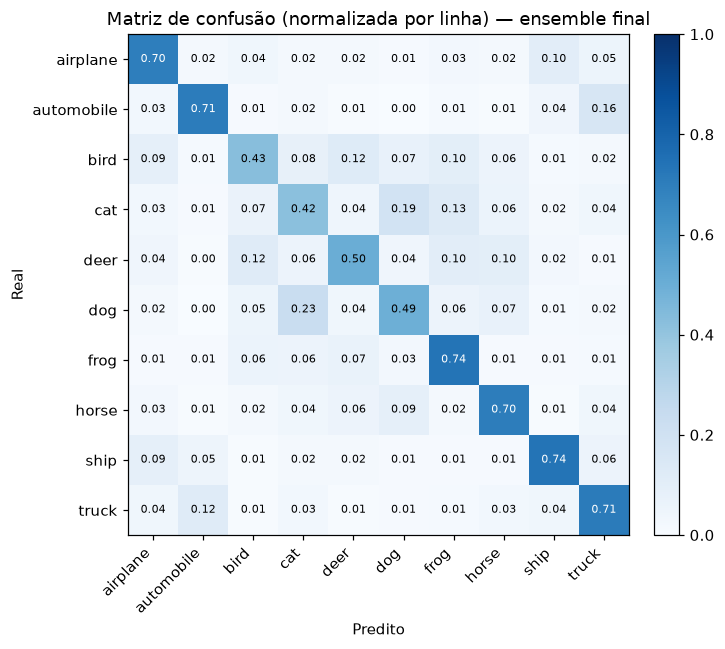

In [8]:
MEMBER_MODEL_IDS = ensemble_meta["members"]

device = torch.device("cpu")
_, _, test_loader = get_dataloaders(data_dir=DATA_DIR, batch_size=256, num_workers=0)


def load_member(model_id):
    run_dir = RESULTS_DIR / model_id
    meta = json.loads((run_dir / "metadata.json").read_text(encoding="utf-8"))
    h = meta["hyperparameters"]
    model = MLP(
        input_size=32 * 32 * 3, num_classes=10,
        hidden_layers=tuple(h["hidden_layers"]), activation=h["activation"],
        dropout=h["dropout"], batch_norm=h["batch_norm"],
    )
    model.load_state_dict(torch.load(run_dir / "model.pt", map_location=device))
    model.to(device).eval()
    return model, h.get("normalization", "default")


@torch.no_grad()
def collect_probs(model, loader):
    probs, targets = [], []
    for images, labels in loader:
        probs.append(F.softmax(model(images.to(device)), dim=1).cpu())
        targets.append(labels)
    return torch.cat(probs), torch.cat(targets)


test_loader_cache = {}
member_probs, targets = [], None
for model_id in MEMBER_MODEL_IDS:
    model, normalization = load_member(model_id)
    if normalization not in test_loader_cache:
        _, _, test_loader_cache[normalization] = get_dataloaders(data_dir=DATA_DIR, batch_size=256, num_workers=0, normalization=normalization)
    p, t = collect_probs(model, test_loader_cache[normalization])
    member_probs.append(p)
    targets = t

avg_probs = torch.stack(member_probs).mean(dim=0)
preds = avg_probs.argmax(dim=1)

cm = confusion_matrix(targets.numpy(), preds.numpy(), normalize="true")

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(10)); ax.set_xticklabels(classes, rotation=45, ha="right")
ax.set_yticks(range(10)); ax.set_yticklabels(classes)
ax.set_xlabel("Predito"); ax.set_ylabel("Real")
ax.set_title("Matriz de confusão (normalizada por linha) — ensemble final")
for i in range(10):
    for j in range(10):
        val = cm[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7, color="white" if val > 0.5 else "black")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "confusion_matrix_ensemble.png")
plt.show()

## 7. Arquivos gerados

Todos salvos em `../results/plots/report/`, prontos para embutir no README com `![descrição](results/plots/report/arquivo.png)`:

- `top15_accuracy.png`
- `evolucao_por_rodada.png`
- `training_curves_melhor_modelo.png`
- `per_class_comparison.png`
- `confusion_matrix_ensemble.png`

In [9]:
for p in sorted(PLOTS_DIR.glob("*.png")):
    print(p.relative_to(PROJECT_ROOT))

results\plots\report\confusion_matrix_ensemble.png
results\plots\report\evolucao_por_rodada.png
results\plots\report\per_class_comparison.png
results\plots\report\top15_accuracy.png
results\plots\report\training_curves_melhor_modelo.png
